**Final evaluation setup**

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FINAL_MODEL_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "stacked_lstm"
    / "stacked_lstm_32_32_20_epochs.keras"
)

FINAL_CONFIG_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "stacked_lstm"
    / "final_config.json"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nModel:")
print(FINAL_MODEL_PATH)

print("\nConfig:")
print(FINAL_CONFIG_PATH)

Project root:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction

Model:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\stacked_lstm\stacked_lstm_32_32_20_epochs.keras

Config:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\stacked_lstm\final_config.json


**Load final configuration**

In [2]:
with open(
    FINAL_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    final_config = json.load(file)

print(
    json.dumps(
        final_config,
        indent=4,
    )
)

{
    "dataset": "Sleep-EDF Expanded",
    "subjects": 197,
    "eeg_channel": "EEG Fpz-Cz",
    "sampling_frequency_hz": 100.0,
    "features": [
        "delta_absolute",
        "theta_absolute",
        "alpha_absolute",
        "beta_absolute",
        "delta_relative",
        "theta_relative",
        "alpha_relative",
        "beta_relative",
        "spectral_entropy",
        "dominant_frequency"
    ],
    "sequence_length_epochs": 20,
    "epoch_duration_seconds": 30,
    "temporal_context_minutes": 10,
    "model": "stacked_lstm",
    "lstm_units": [
        32,
        32
    ],
    "dropout": 0.3,
    "loss": "unweighted_sparse_categorical_crossentropy",
    "optimizer": "Adam",
    "initial_learning_rate": 0.001,
    "batch_size": 256,
    "classes": [
        "W",
        "N1",
        "N2",
        "N3",
        "REM"
    ],
    "random_seed": 42
}


**Load frozen final model**

In [3]:
final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

final_model.summary()

Model: "stacked_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 32)         │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,969 (163.95 KB)

 Trainable params: 13,989 (54.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,980 (109.30 KB)

**Load final feature dataset**

In [4]:
from src.preprocessing.normalization import (
    SleepFeatureScaler,
)

from src.preprocessing.sequences import (
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
)

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

split_df = pd.read_csv(
    SPLIT_PATH
)

df = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

train_df = (
    df[
        df["split"] == "train"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

val_df = (
    df[
        df["split"] == "val"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

test_df = (
    df[
        df["split"] == "test"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

print(
    "Train:",
    train_df.shape,
)

print(
    "Validation:",
    val_df.shape,
)

print(
    "Test:",
    test_df.shape,
)

Train: (319628, 17)
Validation: (69602, 17)
Test: (68347, 17)


**Recreate final normalization**

In [5]:
feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    "Train scaled:",
    X_train_scaled.shape,
)

print(
    "Validation scaled:",
    X_val_scaled.shape,
)

print(
    "Test scaled:",
    X_test_scaled.shape,
)

Train scaled: (319628, 10)
Validation scaled: (69602, 10)
Test scaled: (68347, 10)


**Build final 20-epoch test sequences**

In [6]:
X_test_final, y_test_final_labels = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=20,
    )
)

y_test_final = (
    encode_sleep_stage_labels(
        y_test_final_labels
    )
)

print(
    "Final test sequences:",
    X_test_final.shape,
)

print(
    "Final test labels:",
    y_test_final.shape,
)

Final test sequences: (67017, 20, 10)
Final test labels: (67017,)


**Generate final predictions**

In [7]:
test_probabilities = (
    final_model.predict(
        X_test_final,
        batch_size=256,
        verbose=1,
    )
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)

print(
    "Probability shape:",
    test_probabilities.shape,
)

print(
    "Prediction shape:",
    test_predictions.shape,
)

print(
    "Label shape:",
    y_test_final.shape,
)

262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Probability shape: (67017, 5)
Prediction shape: (67017,)
Label shape: (67017,)


**Final classification report**

In [8]:
CLASS_NAMES = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

final_report = classification_report(
    y_test_final,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)

print(final_report)

              precision    recall  f1-score   support

           W     0.9608    0.9615    0.9612     43009
          N1     0.4333    0.3383    0.3800      2891
          N2     0.7667    0.7907    0.7785     13160
          N3     0.8421    0.6480    0.7324      2855
         REM     0.6695    0.7809    0.7209      5102

    accuracy                         0.8740     67017
   macro avg     0.7345    0.7039    0.7146     67017
weighted avg     0.8727    0.8740    0.8722     67017



**Final evaluation metrics**

In [9]:
final_metrics = {
    "accuracy": accuracy_score(
        y_test_final,
        test_predictions,
    ),

    "balanced_accuracy": (
        balanced_accuracy_score(
            y_test_final,
            test_predictions,
        )
    ),

    "macro_precision": (
        precision_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_recall": (
        recall_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_f1": (
        f1_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "weighted_f1": (
        f1_score(
            y_test_final,
            test_predictions,
            average="weighted",
            zero_division=0,
        )
    ),
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

display(
    final_metrics_df.round(4)
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,0.874,0.7039,0.7345,0.7039,0.7146,0.8722


**Final confusion matrix**

Final confusion matrix:
[[41353   418  1037    43   158]
 [  728   978   721     2   462]
 [  586   552 10405   302  1315]
 [   64     6   903  1850    32]
 [  309   303   506     0  3984]]


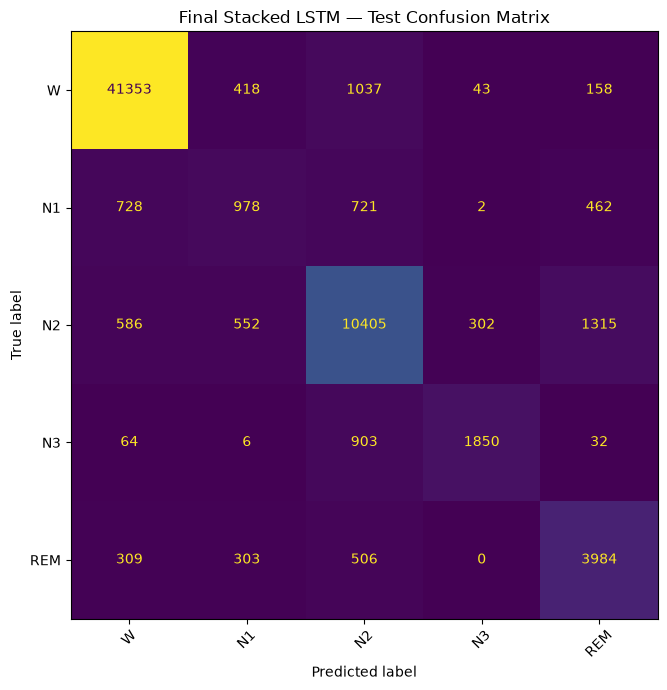

In [10]:
final_cm = confusion_matrix(
    y_test_final,
    test_predictions,
)

print(
    "Final confusion matrix:"
)

print(
    final_cm
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=CLASS_NAMES,
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

cm_display.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
    colorbar=False,
)

ax.set_title(
    "Final Stacked LSTM — Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

**Normalized confusion matrix**

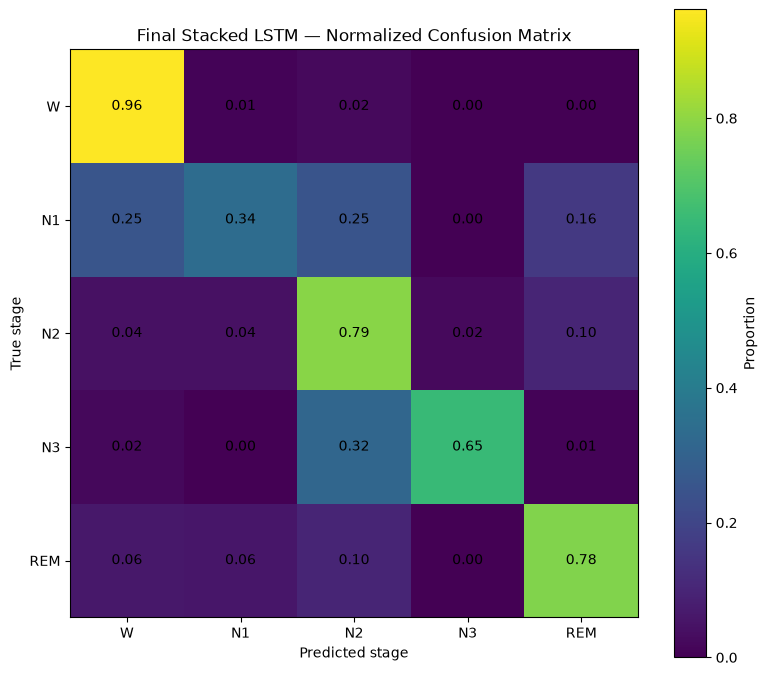

In [11]:
final_cm_normalized = (
    final_cm
    / final_cm.sum(
        axis=1,
        keepdims=True,
    )
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

im = ax.imshow(
    final_cm_normalized
)

ax.set_xticks(
    np.arange(len(CLASS_NAMES))
)

ax.set_yticks(
    np.arange(len(CLASS_NAMES))
)

ax.set_xticklabels(
    CLASS_NAMES
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted stage"
)

ax.set_ylabel(
    "True stage"
)

ax.set_title(
    "Final Stacked LSTM — Normalized Confusion Matrix"
)

for i in range(
    len(CLASS_NAMES)
):
    for j in range(
        len(CLASS_NAMES)
    ):
        ax.text(
            j,
            i,
            f"{final_cm_normalized[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.colorbar(
    im,
    ax=ax,
    label="Proportion",
)

plt.tight_layout()
plt.show()

**Save final evaluation artifacts**

In [12]:
FINAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

final_metrics_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_metrics.csv",
    index=False,
)

pd.DataFrame(
    final_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).to_csv(
    FINAL_RESULTS_DIR
    / "final_confusion_matrix.csv"
)

print(
    "Final evaluation results saved to:"
)

print(
    FINAL_RESULTS_DIR
)

Final evaluation results saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation


**Save per-class metrics**

In [13]:
final_report_dict = classification_report(
    y_test_final,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=6,
    zero_division=0,
    output_dict=True,
)

final_per_class_df = (
    pd.DataFrame(
        final_report_dict
    ).T
)

final_per_class_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_classification_report.csv"
)

display(
    final_per_class_df.round(4)
)

,precision,recall,f1-score,support
W,0.9608,0.9615,0.9612,43009.000
N1,0.4333,0.3383,0.3800,2891.000
N2,0.7667,0.7907,0.7785,13160.000
N3,0.8421,0.6480,0.7324,2855.000
REM,0.6695,0.7809,0.7209,5102.000
accuracy,0.8740,0.8740,0.8740,0.874
macro avg,0.7345,0.7039,0.7146,67017.000
weighted avg,0.8727,0.8740,0.8722,67017.000


**Save final predictions**

In [14]:
final_prediction_df = pd.DataFrame(
    {
        "true_stage": [
            CLASS_NAMES[i]
            for i in y_test_final
        ],

        "predicted_stage": [
            CLASS_NAMES[i]
            for i in test_predictions
        ],

        "prob_W": test_probabilities[:, 0],
        "prob_N1": test_probabilities[:, 1],
        "prob_N2": test_probabilities[:, 2],
        "prob_N3": test_probabilities[:, 3],
        "prob_REM": test_probabilities[:, 4],
    }
)

final_prediction_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_predictions.csv",
    index=False,
)

print(
    "Saved:",
    FINAL_RESULTS_DIR
    / "final_predictions.csv"
)

Saved: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation\final_predictions.csv


**Final experiment summary**

In [15]:
experiment_summary = pd.DataFrame(
    [
        {
            "experiment": "Weighted loss",
            "accuracy": 0.7762,
            "balanced_accuracy": 0.7454,
            "macro_f1": 0.6431,
            "weighted_f1": 0.8006,
        },
        {
            "experiment": "Moderated weighting",
            "accuracy": 0.7983,
            "balanced_accuracy": 0.7111,
            "macro_f1": 0.6554,
            "weighted_f1": 0.8146,
        },
        {
            "experiment": "Unweighted loss",
            "accuracy": 0.8589,
            "balanced_accuracy": 0.7046,
            "macro_f1": 0.7024,
            "weighted_f1": 0.8601,
        },
        {
            "experiment": "5 epochs",
            "accuracy": 0.8387,
            "balanced_accuracy": 0.6800,
            "macro_f1": 0.6746,
            "weighted_f1": 0.8403,
        },
        {
            "experiment": "10 epochs",
            "accuracy": 0.8410,
            "balanced_accuracy": 0.6821,
            "macro_f1": 0.6795,
            "weighted_f1": 0.8442,
        },
        {
            "experiment": "20 epochs",
            "accuracy": 0.8602,
            "balanced_accuracy": 0.6985,
            "macro_f1": 0.7017,
            "weighted_f1": 0.8614,
        },
        {
            "experiment": "LSTM(32)",
            "accuracy": 0.8662,
            "balanced_accuracy": 0.7004,
            "macro_f1": 0.7081,
            "weighted_f1": 0.8670,
        },
        {
            "experiment": "LSTM(64)",
            "accuracy": 0.8602,
            "balanced_accuracy": 0.6985,
            "macro_f1": 0.7017,
            "weighted_f1": 0.8614,
        },
        {
            "experiment": "LSTM(128)",
            "accuracy": 0.8332,
            "balanced_accuracy": 0.6656,
            "macro_f1": 0.6546,
            "weighted_f1": 0.8413,
        },
        {
            "experiment": "Stacked LSTM(32+32)",
            "accuracy": 0.8740,
            "balanced_accuracy": 0.7039,
            "macro_f1": 0.7146,
            "weighted_f1": 0.8722,
        },
        {
            "experiment": "Bidirectional LSTM",
            "accuracy": 0.8651,
            "balanced_accuracy": 0.7067,
            "macro_f1": 0.7070,
            "weighted_f1": 0.8671,
        },
        {
            "experiment": "Attention LSTM",
            "accuracy": 0.8452,
            "balanced_accuracy": 0.6817,
            "macro_f1": 0.6733,
            "weighted_f1": 0.8506,
        },
    ]
)

display(
    experiment_summary.round(4)
)

,experiment,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Weighted loss,0.7762,0.7454,0.6431,0.8006
1,Moderated weighting,0.7983,0.7111,0.6554,0.8146
2,Unweighted loss,0.8589,0.7046,0.7024,0.8601
3,5 epochs,0.8387,0.6800,0.6746,0.8403
4,10 epochs,0.8410,0.6821,0.6795,0.8442
5,20 epochs,0.8602,0.6985,0.7017,0.8614
6,LSTM(32),0.8662,0.7004,0.7081,0.8670
7,LSTM(64),0.8602,0.6985,0.7017,0.8614
8,LSTM(128),0.8332,0.6656,0.6546,0.8413
9,Stacked LSTM(32+32),0.8740,0.7039,0.7146,0.8722


**Save final experiment summary**

In [16]:
experiment_summary.to_csv(
    FINAL_RESULTS_DIR
    / "experiment_summary.csv",
    index=False,
)

**Multi-seed stability experiment**

In [ ]:
from src.models.lstm import (
    build_stacked_lstm,
    compile_baseline_lstm,
)

SEEDS = [42, 123, 456]


def run_final_seed_experiment(seed):
    """
    Train the frozen final architecture with one random seed.
    """

    set_experiment_seed(seed)

    model = build_stacked_lstm(
        sequence_length=20,
        n_features=10,
        n_classes=5,
        lstm_units=32,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train_scaled,
                y_train_final_labels
                if False
                else None,
            )
        )
    )